# 02 - Diagnostics

Everything that validated the model but never runs again in production:
leakage audits, VIF, nested CV, cross-site generalisation, threshold choice,
statsmodels inference, influence, calibration, LR tests.



In [1]:
# --- make src/ importable ------------------------------------------------
import sys
from pathlib import Path

_here = Path.cwd()
for _p in (_here, *_here.parents):
    if (_p / "src" / "disease_pred").is_dir():
        sys.path.insert(0, str(_p / "src"))
        PROJECT = _p
        break
else:
    raise RuntimeError("could not locate src/disease_pred above %s" % _here)
print("project root:", PROJECT)

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, brier_score_loss,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (LeaveOneGroupOut, cross_val_predict,
                                     cross_validate)
from sklearn.pipeline import Pipeline

from disease_pred.config import (MAX_ITER, PARAMS, SEED, SPEC_PATH, REPORTS_DIR, cv)
from disease_pred.data import prepare
from disease_pred.features import build_preprocessor, output_names
from disease_pred.evaluate import score
from disease_pred.train import build_search, cost_threshold, oof_predictions

RANDOM_SEED = SEED
FILES = PARAMS['data']['files']

#
prepared = prepare()
X_train, X_test = prepared['X_train'], prepared['X_test']
y_train, y_test = prepared['y_train'], prepared['y_test']
g_train, g_test = prepared['g_train'], prepared['g_test']
spec = prepared['spec']

NUMERIC, BINARY, CATEGORICAL ,INDICATORS= spec['numeric'], spec['binary'], spec['categorical'],spec["indicators"]

print(f'design mat train {X_train.shape} \ndesign matrix test {X_test.shape}'
      f'\ntrain prevalance {y_train.mean():.3f} test prevalance {y_test.mean():.3f}')
print('dropped for missingness:', spec['dropped_high_missing'])

project root: e:\AI_ML\Prac\Logistic Regression\disease prediction project
design mat train (688, 10) 
design matrix test (230, 10)
train prevalance 0.554 test prevalance 0.552
dropped for missingness: ['thal', 'slope', 'ca']


## missing inidcator

since we have missing values , lets see if indicator has nay leakage

One-time justification for keeping the `MissingIndicator` block in
`features.build_preprocessor`.

In [2]:
ind_audit=[]
for c in X_train.columns:
    m=X_train[c].isna().astype(int)
    if m.sum() and m.sum() < len(m):
        ind_audit.append({
            'column':c,
            'missing_pct':X_train[c].isna().mean()*100,
            'auc_Indicator':round(roc_auc_score(y_train,m),2)
        })
pd.DataFrame(ind_audit).sort_values('auc_Indicator',ascending=False)

,column,missing_pct,auc_Indicator
1,chol,21.656977,0.60
4,fbs,9.156977,0.55
0,trestbps,6.976744,0.52
2,thalach,6.540698,0.51
3,oldpeak,7.122093,0.51
5,exang,6.540698,0.51


## `features.build_preprocessor()`


In [3]:
preprocessor = build_preprocessor(NUMERIC, BINARY, CATEGORICAL,INDICATORS)
preprocessor.fit(X_train, y_train)
feature_names = output_names(preprocessor)
feature_names, len(feature_names)

(['age',
  'trestbps',
  'chol',
  'thalach',
  'oldpeak',
  'sex',
  'fbs',
  'cp_2.0',
  'cp_3.0',
  'cp_4.0',
  'restecg_1.0',
  'restecg_2.0',
  'exang_1.0',
  'missingindicator_trestbps',
  'missingindicator_thalach',
  'missingindicator_oldpeak'],
 16)

## VIF and the inference design

`Zc_inf` is built for **statsmodels inference only** -- ORs, p-values, LR
tests, Cook's distance. It never goes to production and never touches
`model.joblib`. Keeping it inside this notebook is what stops anyone later
mistaking it for the model.

In [4]:
Z_train=pd.DataFrame(preprocessor.transform(X_train),columns=feature_names,index=X_train.index)
keep=Z_train.columns[Z_train.std()>1e-8]
dropped=set(Z_train.columns)-set(keep)
if dropped:
    print(f'dropping zero variance columns {dropped}')
Z_train=Z_train[keep]

Zc=sm.add_constant(Z_train,has_constant='add')
vif=pd.DataFrame({
    'features':Zc.columns,
    'vif': [variance_inflation_factor(Zc.values,c) for c in range(Zc.shape[1])]
})
vif[vif.features != 'const'].sort_values('vif',ascending=False)

,features,vif
15,missingindicator_thalach,18.416867
14,missingindicator_trestbps,16.031775
16,missingindicator_oldpeak,8.272292
10,cp_4.0,6.245865
9,cp_3.0,4.520518
8,cp_2.0,4.275781
13,exang_1.0,1.522873
4,thalach,1.455066
1,age,1.403508
5,oldpeak,1.291171


### 

missing indicators having vif >10 are all from VA , prediction model will be fine as it will regularised. but stats model inference will be broken. SE will be inflated , Ci will be too narrow  , p values will become un intrepretable . lets collapse them into 1

In [5]:
va_battery_cols = ['missingindicator_trestbps', 'missingindicator_thalach', 'missingindicator_oldpeak']

Z_train_inf = Z_train.copy()
Z_train_inf['missingindicator_va_battery'] = Z_train_inf[va_battery_cols].max(axis=1)
Z_train_inf = Z_train_inf.drop(columns=va_battery_cols)

Zc_inf = sm.add_constant(Z_train_inf, has_constant='add')
vif_inf = pd.DataFrame({
    'features': Zc_inf.columns,
    'vif': [variance_inflation_factor(Zc_inf.values, c) for c in range(Zc_inf.shape[1])]
})
vif_inf[vif_inf.features != 'const'].sort_values('vif', ascending=False)

,features,vif
10,cp_4.0,6.245656
9,cp_3.0,4.521031
8,cp_2.0,4.274050
13,exang_1.0,1.519769
4,thalach,1.447764
1,age,1.392974
5,oldpeak,1.281661
11,restecg_1.0,1.201036
14,missingindicator_va_battery,1.195806
12,restecg_2.0,1.168239


In [6]:
r,k =np.linalg.matrix_rank(Zc.values),Zc.shape[1]
assert r==k #verifying no  identifiability 

## dummy baselines



In [7]:
#dummy baseline
rows=[]

for strat in ['prior','most_frequent','stratified']:
    dm=DummyClassifier(strategy=strat,random_state=RANDOM_SEED).fit(X_train,y_train)
    rows.append(score(y_train,dm.predict_proba(X_train)[:,1],name=f'dummy {strat}',split='train'))

pd.DataFrame(rows)

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,avg_precision,brier
0,dummy prior,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.247
1,dummy most_frequent,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.446
2,dummy stratified,train,0.5,0.510,0.558,0.559,0.558,0.504,0.556,0.490


##  unregularised baseline

A comparison point, not the deliverable.

In [8]:
base_logreg=Pipeline([('pre',preprocessor),
                      ('baselogReg',LogisticRegression(max_iter=MAX_ITER,random_state=RANDOM_SEED))]).fit(X_train,y_train)

rows.append(score(y_train,base_logreg.predict_proba(X_train)[:,1],name='base log reg',split='train'))
pd.DataFrame(rows)

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,avg_precision,brier
0,dummy prior,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.247
1,dummy most_frequent,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.446
2,dummy stratified,train,0.5,0.510,0.558,0.559,0.558,0.504,0.556,0.490
3,base log reg,train,0.5,0.815,0.819,0.856,0.837,0.881,0.888,0.137


## `train.build_search()`


In [9]:
gs = build_search(NUMERIC, BINARY, CATEGORICAL,INDICATORS)
gs.fit(X_train, y_train)
print(f' best params :{gs.best_params_}')
print(f' best score : {-gs.best_score_}')

 best params :{'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.0}
 best score : 0.4502428578377639


##  is the CV estimate reportable?

In [10]:
res=pd.DataFrame(gs.cv_results_)
res.columns
cols=['mean_train_auc','mean_test_auc', 'std_test_auc','mean_train_log_loss','mean_test_log_loss', 'std_test_log_loss',
      'param_clf__C','param_clf__l1_ratio']
res=res[cols].copy()
res['gap log loss']=res['mean_train_log_loss']-res['mean_test_log_loss']
res['gap_auc']=res['mean_train_auc']-res['mean_test_auc']
res.sort_values('param_clf__C')[['param_clf__l1_ratio','gap log loss','gap_auc']]
aa=res.pivot_table(index='param_clf__C', columns='param_clf__l1_ratio',values=['gap log loss','gap_auc'], aggfunc='mean')
aa.columns= [f'{k}_l1_penalty{c}' for k,c in aa.columns]
aa

,gap log loss_l1_penalty0.0,gap log loss_l1_penalty0.25,gap log loss_l1_penalty0.5,gap log loss_l1_penalty0.75,gap log loss_l1_penalty1.0,gap_auc_l1_penalty0.0,gap_auc_l1_penalty0.25,gap_auc_l1_penalty0.5,gap_auc_l1_penalty0.75,gap_auc_l1_penalty1.0
param_clf__C,,,,,,,,,,
0.000010,0.000019,-0.000016,-0.000016,-0.000007,0.000067,0.005154,0.000000,0.000000,0.000000,0.000000
0.000032,0.000042,-0.000006,0.000007,0.000033,0.000067,0.005224,0.000000,0.000000,0.000000,0.000000
0.000100,0.000111,0.000035,0.000047,0.000058,0.000067,0.005513,0.000000,0.000000,0.000000,0.000000
0.000316,0.000319,0.000069,0.000062,0.000064,0.000067,0.005472,0.000000,0.000000,0.000000,0.000000
0.001000,0.000892,0.000048,0.000075,0.000076,0.000067,0.005822,0.000000,0.000000,0.000000,0.000000
0.003162,0.002256,0.000439,0.000049,0.000105,0.000056,0.005395,0.000177,0.000000,0.000000,0.000000
0.010000,0.005023,0.003075,0.001628,0.000816,0.000537,0.006638,0.005186,0.003695,0.000116,0.000345
0.031623,0.009620,0.007686,0.007634,0.005742,0.003393,0.008777,0.006693,0.006296,0.005714,0.003164
0.100000,0.015392,0.014235,0.012482,0.012926,0.014400,0.011525,0.010785,0.009098,0.010029,0.011528


### Cell 39

c is not pinned to boundaries, so our range was ok.  gap grows continuously, steepest between C=0.01-1, and our chosen C sits inside that growth region, not before it

In [11]:
nested = cross_validate(
    gs, X_train, y_train, cv=cv,
    scoring={'log_loss': 'neg_log_loss', 'auc': 'roc_auc', 'ap': 'average_precision'},
    return_estimator=True,n_jobs=-1
)

In [12]:
nested.keys()

dict_keys(['fit_time', 'score_time', 'estimator', 'test_log_loss', 'test_auc', 'test_ap'])

In [13]:
nested.keys()
pd.DataFrame({k: nested[k] for k in ['test_log_loss', 'test_auc', 'test_ap']})

,test_log_loss,test_auc,test_ap
0,-0.465016,0.859720,0.872305
1,-0.399055,0.899194,0.914501
2,-0.474218,0.852885,0.853126
3,-0.481823,0.846851,0.883369
4,-0.434092,0.880069,0.878730


In [14]:
[e.best_params_ for e in nested['estimator']]

[{'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.5},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.0},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.5},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.0},
 {'clf__C': np.float64(0.31622776601683794), 'clf__l1_ratio': 0.75}]

C = 0.316 was selected in all 5 outer folds. l1_ratio varied (0.0, 0.5, 0.75),so the L1/L2 mix is not pinned down, but test loss is nearly flat along it and the nested score is unaffected.

In [15]:

scores = pd.DataFrame({
    'log_loss': -nested['test_log_loss'],
    'auc': nested['test_auc'],
    'ap': nested['test_ap']
})
summary = scores.agg(['mean', 'std'])
print(summary)

single_split = -gs.best_score_
nested_mean = summary.loc['mean', 'log_loss']
nested_std = summary.loc['std', 'log_loss']

print(f"\nsingle-split (gs.best_score_): {single_split:.4f}")
print(f"nested CV: {nested_mean:.4f} +/- {nested_std:.4f}")
print(f"within 1 nested std: {abs(single_split - nested_mean) <= nested_std}")

      log_loss       auc        ap
mean  0.450841  0.867744  0.880406
std   0.034167  0.021579  0.022271

single-split (gs.best_score_): 0.4502
nested CV: 0.4508 +/- 0.0342
within 1 nested std: True


## Cell 47 -- coefficient sparsity

In [16]:
final_model=gs.best_estimator_

coef=pd.Series(final_model.named_steps['clf'].coef_[0],index=feature_names)
# coef
print(f'non zero coefficinets: {(coef.abs()>1e-6).sum()} / {len(coef)}')
coef[coef.abs()>1e-6].sort_values(key=abs,ascending=False)

non zero coefficinets: 16 / 16


sex                          1.130534
cp_4.0                       0.992031
exang_1.0                    0.952375
cp_2.0                      -0.840149
oldpeak                      0.486444
thalach                     -0.442232
age                          0.284497
restecg_1.0                  0.283948
chol                         0.217517
missingindicator_trestbps    0.207772
cp_3.0                      -0.179597
fbs                          0.157499
missingindicator_oldpeak     0.144351
restecg_2.0                  0.137036
missingindicator_thalach     0.118202
trestbps                     0.015394
dtype: float64

## leave-one-site-out

In [17]:
#leave one group out cv to make sure it works for sites other than mentioned 4
logo=LeaveOneGroupOut()
# scores=cross_val_score(final_model,X,y,groups=groups,cv=logo,scoring='neg_log_loss')
# scores_auc=cross_val_score(final_model,X,y,groups=groups,cv=logo,scoring='roc_auc')

nested_scores=cross_validate(final_model,X_train,y_train,groups=g_train,cv=logo,scoring={'log_loss': 'neg_log_loss', 'auc': 'roc_auc', 'ap': 'average_precision'})
# print(dict(zip(FILES,-scores)))
# dict(zip(FILES,scores_auc))
nested_scores.keys()

dict_keys(['fit_time', 'score_time', 'test_log_loss', 'test_auc', 'test_ap'])

In [18]:
g_train.unique()

<StringArray>
['hungary', 'switzerland', 'va', 'cleveland']
Length: 4, dtype: str

In [19]:
pd.DataFrame({ k : nested_scores[k] for k in ['test_log_loss', 'test_auc', 'test_ap']},index=sorted(g_train.unique()))

,test_log_loss,test_auc,test_ap
cleveland,-0.492775,0.853204,0.851175
hungary,-0.436860,0.892279,0.867201
switzerland,-0.560320,0.731922,0.966110
va,-0.530289,0.712251,0.864690




LOGO CV: cleveland 0.853 and hungary 0.892 AUC, within about 1 nested std of
the 5-fold nested mean (0.868). switzerland 0.732 and va 0.712 are well below
it, a real generalization gap and not fold noise. switzerland AP (0.966) is
mostly its 93% prevalence, so AUC is the fair read, and with very few
negatives that AUC is noisy. The drop is consistent with the model leaning on
site-linked missingness (indicator coefficients), but this is untested.
Ablation without those indicators is needed to attribute it. Headline: 5-fold
nested AUC 0.868 is a within-site estimate. Across held-out sites AUC ranged
0.71-0.89 (mean about 0.80).

> **-> model card.** This is the headline generalisation caveat.

## threshold selection

In [20]:
#choosing threshold
p_oof = oof_predictions(final_model, X_train, y_train)

prec,rec,thr=precision_recall_curve(y_train,p_oof)
f1s= 2* prec * rec/(prec+rec+1e-12)
t_f1=thr[np.nanargmax(f1s[:-1])]

TARGET_RECALL=PARAMS['decision']['target_recall']
ok=np.where(rec[:-1]> TARGET_RECALL)[0]
t_recall=thr[ok[np.argmax(prec[:-1][ok])]]

C_FP,C_FN=PARAMS['decision']['cost_fp'],PARAMS['decision']['cost_fn']  #bayes rule
t_cost=cost_threshold()

print(f'F1-optimal      t = {t_f1:.3f}')
print(f'recall >= {TARGET_RECALL}  t = {t_recall:.3f}')
print(f'cost-optimal    t = {t_cost:.3f}  (c_FN = {C_FN/C_FP:.0f}x c_FP)')
len(p_oof)

F1-optimal      t = 0.412
recall >= 0.9  t = 0.382
cost-optimal    t = 0.200  (c_FN = 4x c_FP)


688

In [21]:
cv_oof_newSite=cross_val_predict(final_model,X_train,y_train,cv=logo,groups=g_train,method='predict_proba')[:,1]
prec1,rec1,thres1=precision_recall_curve(y_train,cv_oof_newSite)
f1s1=2 * prec1 * rec1/(prec1+rec1+1e-12)
t_f11=thres1[np.nanargmax(f1s1[:-1])]

ok1=np.where(rec1[:-1]>TARGET_RECALL)[0]
t_recall1=thres1[ok[np.argmax(prec1[:-1][ok1])]]

print(f'{t_f11:.3f}')
print(f'{t_recall1:.3f}')

0.348
0.397


##  threshold sweep and ROC

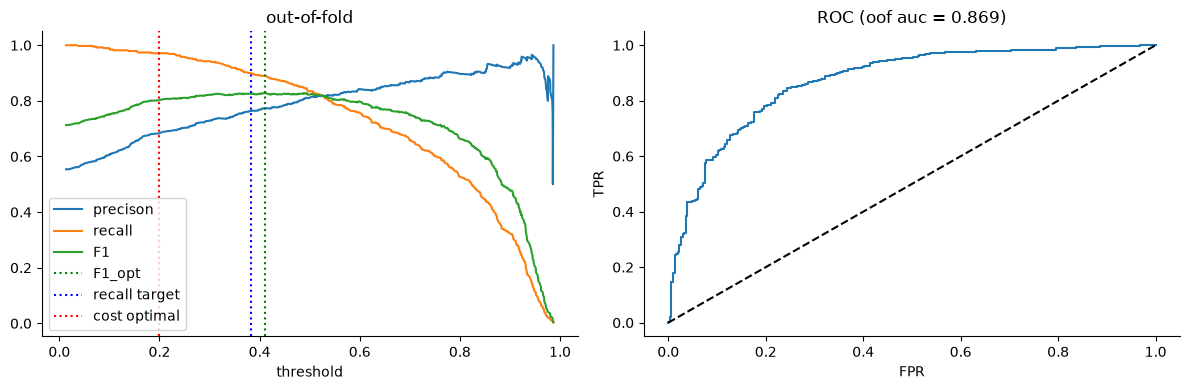

In [23]:
fig, ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(thr,prec[:-1],label='precison')
ax[0].plot(thr,rec[:-1],label='recall')
ax[0].plot(thr,f1s[:-1],label='F1')

for t,lab,col in [(t_f1,'F1_opt','g'),(t_recall,'recall target','b'),
                  (t_cost,'cost optimal','r')]:
    ax[0].axvline(t,ls=':',c=col,label=lab)
ax[0].set_xlabel('threshold'); ax[0].legend(); ax[0].set_title('out-of-fold')

fpr,tpr,_=roc_curve(y_train,p_oof)
ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
ax[1].set_title(f'ROC (oof auc = {roc_auc_score(y_train, p_oof):.3f})')
[ax.spines[['top','right']].set_visible(False) for ax in fig.axes]
plt.tight_layout()



chose t_cost (0.2) over t_f1 (0.43): a missed diagnosis (fn) is 4x costlier here than an unnecessary follow-up (fp), so the bayes-optimal threshold C_FP/(C_FP+C_FN)=0.2 is the principled pick, not the symmetric f1 peak. at t=0.2, recall~0.97 vs ~0.83 at t_f1, for only a modest f1 dip (~0.80 vs ~0.84 peak) - the curve shape favors this trade. t_recall (0.405, targeting recall>=0.9) is arbitrary by comparison since 0.9 was a round number, not a cost estimate - t_cost is grounded in an actual cost ratio. this assumes p_oof is calibrated, not just well-ranked - worth a brier/reliability check on the final model .

> **-> model card.** The threshold rationale.

 is p_oof calibrated?

In [24]:
brier_score_loss(y_train, p_oof)

0.14375540589707206

oof brier = 0.144 vs no-skill baseline 0.247 (dummy prior), brier skill score ( brier version of Rsq)
about 0.42, a real improvement. in-sample brier for base_logreg = 0.137 (skill
about 0.45), so the oof minus in-sample gap is about 0.007, a modest
overfitting gap consistent with the C-vs-gap analysis. both scores rose by
about 0.007 after switching to the explicit 3-flag indicator list (chol and
fbs flags removed), consistent with those flags having carried site-linked
signal. brier does not test calibration, so the threshold of 0.2 still needs a
calibration curve on oof probabilities.

 the threshold is an artifact

`THRESHOLD = 0.2` looks like a constant. It isn't: it was derived from
out-of-fold predictions under a stated 4:1 cost ratio and rests on a
calibration assumption validated just above. It is as much a fitted quantity
as any coefficient, so `train.py` writes it into `models/feature_spec.json`
and it is **read back** here rather than retyped.

In [25]:
THRESHOLD = json.loads(SPEC_PATH.read_text(encoding='utf-8'))['threshold']
print('chosen threshold:', round(THRESHOLD, 3))
assert THRESHOLD == t_cost, 'saved artifact drifted from the params.yaml cost ratio'

chosen threshold: 0.2


## statsmodels inference

Pure inference on `Zc_inf`. Never goes near `serve.py`.

In [26]:
logit_composite=sm.Logit(y_train,Zc_inf).fit(disp=0)
print(logit_composite.summary2())

                              Results: Logit
Model:                  Logit               Method:              MLE       
Dependent Variable:     target              Pseudo R-squared:    0.374     
Date:                   2026-10-04 23:36    AIC:                 621.7283  
No. Observations:       688                 BIC:                 689.7351  
Df Model:               14                  Log-Likelihood:      -295.86   
Df Residuals:           673                 LL-Null:             -472.90   
Converged:              1.0000              LLR p-value:         5.7690e-67
No. Iterations:         6.0000              Scale:               1.0000    
---------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------------------
const                       -1.6205   0.4698 -3.4495 0.0006 -2.5413 -0.6998
age                          0.3065   0.123

### Cell 58

logit on Zc_inf (collapsed va-battery, no multicollinearity issues): pseudo r2=0.399, llr p~2e-70 - model fits well overall. sex/exang/oldpeak/thalach/chol/cp_4 significant and clinically sensible directions. trestbps/fbs/restecg/cp_3 not significant, could prune for a leaner model. age (p=0.065) and missingindicator_va_battery (p=0.062) borderline - age's effect absorbed by thalach/oldpeak/cp being age-correlated.

missingindicator_chol (p=0.033) and missingindicator_fbs (p=0.009, largest indicator coef) are significant now that vif is resolved - but stable is not generalizable. logo cv already showed the model underperforms on switzerland/va and traced it to these same two indicators. treat their coeficients as real within sample associations, not confirmed physiological effects , partly site-driven, not something to report as a clean clinical finding.

next step: fit without missingindicator_chol (p=0.033) and missingindicator_fbs, rerun LOGO and see if auc gap narrows - then we would have better cross site generalisation , much stronger case then current circumstancial one .

In [27]:
ci=logit_composite.conf_int()
ci

,0,1
const,-2.541301,-0.699780
age,0.064298,0.548763
trestbps,-0.208752,0.226139
chol,0.037665,0.455705
thalach,-0.671046,-0.184812
oldpeak,0.240641,0.718132
sex,0.860707,1.933489
fbs,-0.433205,0.770180
cp_2.0,-2.013024,-0.102179
cp_3.0,-1.124760,0.632033


In [28]:
odds=pd.DataFrame({
    'coef':logit_composite.params,
    'OR':np.exp(logit_composite.params),
    'OR_lo':np.exp(ci[0]),
    'OR_hi':np.exp(ci[1]),
    'p': logit_composite.pvalues
}).drop(index='const').sort_values('OR',ascending=False)
odds.round(3)

,coef,OR,OR_lo,OR_hi,p
sex,1.397,4.043,2.365,6.914,0.000
exang_1.0,1.111,3.037,1.846,4.996,0.000
cp_4.0,0.997,2.710,1.145,6.415,0.023
oldpeak,0.479,1.615,1.272,2.051,0.000
missingindicator_va_battery,0.454,1.574,0.749,3.307,0.231
restecg_1.0,0.341,1.407,0.795,2.489,0.241
age,0.307,1.359,1.066,1.731,0.013
chol,0.247,1.280,1.038,1.577,0.021
restecg_2.0,0.174,1.190,0.708,2.003,0.511
fbs,0.168,1.184,0.648,2.160,0.583


In [30]:
#robust SEs mispecification not heteroscedasticity fix
logit_hc3=sm.Logit(y_train,Zc_inf).fit(cov_type='HC3')
pd.DataFrame({
    'se model':logit_composite.bse, 'se robust':logit_hc3.bse,
    'ratio':(logit_hc3.bse/logit_composite.bse)
}).sort_values('ratio',ascending=False).round(3)

Optimization terminated successfully.
         Current function value: 0.430035
         Iterations 6


,se model,se robust,ratio
cp_3.0,0.448,0.499,1.114
cp_4.0,0.440,0.490,1.114
trestbps,0.111,0.123,1.108
const,0.470,0.511,1.087
fbs,0.307,0.330,1.075
cp_2.0,0.487,0.522,1.071
restecg_1.0,0.291,0.312,1.070
thalach,0.124,0.127,1.022
restecg_2.0,0.265,0.269,1.012
exang_1.0,0.254,0.254,1.001


### Cell 64

ran HC3 sandwich SEs to check whether the model-based p-values/CIs are trustworthy - naive MLE SEs assume the model is exactly correctly specified, and given the site heterogeneity already found in this data (logo cv gap, wide ORs on the missingness indicators), that assumption was worth stress-testing rather than assuming.

all se ratios (robust/model) fall between 0.944 and 1.125 - under 15% movement everywhere, no coefficient flips significance. missingindicator_chol (0.984) and missingindicator_fbs (0.953) don't inflate at all. clean pass: the earlier p-values aren't an artifact of heteroscedasticity or generic misspecification.

HC3 only relaxes constant-variance for independent rows it doesn't test within-site correlation, which is the more relevant structure given everything else found here.

In [31]:
logit_cluster=sm.Logit(y_train, Zc_inf).fit(cov_type='cluster', cov_kwds={'groups': g_train})
pd.DataFrame({
    'se model':logit_composite.bse, 'se robust':logit_cluster.bse,
    'ratio':(logit_cluster.bse/logit_composite.bse)
}).round(3)

Optimization terminated successfully.
         Current function value: 0.430035
         Iterations 6


,se model,se robust,ratio
const,0.470,0.781,1.662
age,0.124,0.074,0.598
trestbps,0.111,0.091,0.819
chol,0.107,0.053,0.494
thalach,0.124,0.173,1.392
oldpeak,0.122,0.199,1.630
sex,0.274,0.254,0.927
fbs,0.307,0.406,1.323
cp_2.0,0.487,0.933,1.914
cp_3.0,0.448,0.472,1.054


### Cell 66

ran cluster-robust SEs (grouped by site, G=4) to directly test the site-correlation hypothesis HC3 couldn't address. story is dramatic , wild ratios  0.18 to 2.22, both directions, no consistent story (age shrinks 82%, cp_2.0 grows 86%, missingindicator_chol grows 122%). this isn't real signal: cluster-robust sandwich SEs need many clusters to be asymptotically valid, and G=4 is far too few - the "meat" matrix here is built from just 4 score contributions, so individual ratios are noisy draws, not trustworthy corrections.

missingindicator_chol's ratio (2.22, the largest in the table) is weakly consistent with the site-confound story already built from logo cv + the OR-width check, but shouldn't be leaned on given G=4 unreliability - and missingindicator_fbs (ratio 1.12) doesn't show the same pattern despite being flagged equally, which cuts against treating this as confirmatory. don't use this check as decisive evidence either way.

the right tool for this specific question is the logo cv already run - a direct empirical held-out-site test that doesn't depend on cluster-asymptotics, which is the more trustworthy source for "does this generalize across sites," not this SE comparison.

negative result. cluster SEs need not be repeated again on this dataset

LOGO is the setteld answer.

> **-> model card.** The G=4 argument.

In [32]:
big=pd.DataFrame({'coef':logit_composite.params,'se':logit_composite.bse})
flag=big[(big.coef.abs()>8) | (big.se.abs()>8 )]
print('separation suspects:' if len(flag) else 'no sepration detected')
flag.round(2)

no sepration detected


,coef,se


## Cells 68-69 -- influence, leverage, Cook's distance

flagged on both: 20 of 688


,age,trestbps,chol,thalach,oldpeak,sex,fbs,cp,restecg,exang,target
183,59.0,178.0,270.0,145.0,4.2,1.0,0.0,1.0,2.0,0.0,0
558,46.0,140.0,272.0,175.0,2.0,1.0,1.0,1.0,0.0,0.0,1
691,62.0,120.0,NaN,134.0,-0.8,1.0,NaN,1.0,2.0,0.0,1
595,58.0,180.0,393.0,110.0,1.0,0.0,0.0,2.0,0.0,1.0,1
811,40.0,106.0,240.0,80.0,0.0,1.0,0.0,3.0,0.0,1.0,0
853,68.0,NaN,181.0,NaN,NaN,1.0,1.0,1.0,1.0,NaN,0
780,51.0,NaN,218.0,NaN,NaN,1.0,1.0,4.0,2.0,NaN,0
387,46.0,180.0,280.0,120.0,0.0,1.0,0.0,4.0,1.0,0.0,0
819,63.0,130.0,NaN,160.0,3.0,1.0,1.0,3.0,1.0,0.0,0
889,57.0,180.0,285.0,120.0,0.8,1.0,1.0,2.0,1.0,0.0,1


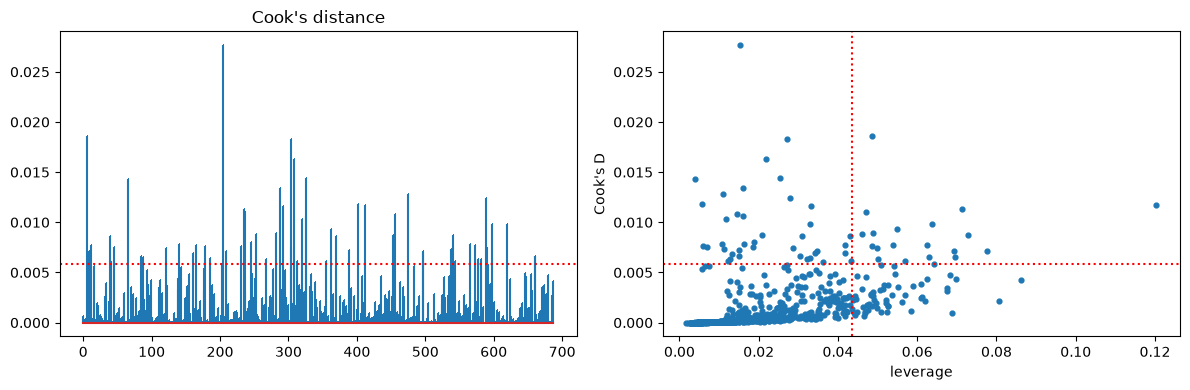

In [33]:
#influence , lev , cook's distance
glm_fit=sm.GLM(y_train,Zc_inf,family=sm.families.Binomial()).fit()
infl=glm_fit.get_influence()
cooks_dis=infl.cooks_distance[0]
hat=infl.hat_matrix_diag

n,p=Zc_inf.shape
cook_cut,hat_cut=4/n,2 *(p/n)

fig,ax=plt.subplots(1,2, figsize=(12,4))
ax[0].stem(np.arange(n),cooks_dis,markerfmt=',')
ax[0].axhline(cook_cut,c='r',ls=':')
ax[0].set_title("Cook's distance")
ax[1].scatter(hat, cooks_dis, s=12)
ax[1].axvline(hat_cut, color='r', ls=':'); ax[1].axhline(cook_cut, color='r', ls=':')
ax[1].set_xlabel('leverage'); ax[1].set_ylabel("Cook's D")
plt.tight_layout()

flag=np.where((cooks_dis>cook_cut)& (hat > hat_cut))[0]
print(f'flagged on both: {len(flag)} of {n}')
# X_train.iloc[flag].head(19)
pd.concat([X_train.iloc[flag],y_train.iloc[flag]],axis=1)

### Cell 69

Left (Cook's D stem, by row index): most stems sit near zero; a handful spike above the red dashed line (cook_cut = 4/n ~ 0.0058) up to ~0.024. Spikes are scattered across the whole index range, not clustered in one block.
Right (leverage vs. Cook's D quadrant plot): this is the classic 4-quadrant read. Bottom-left = typical points (most of the mass). Top-left = high Cook's D but low leverage - points with an unusual outcome given ordinary predictors. Bottom-right = high leverage but low Cook's D - unusual predictor profile that the model still happened to fit fine. Top-right = high leverage AND high Cook's D - unusual predictors and outsized actual influence on the fitted coefficients - that's the genuinely concerning combination, and it's exactly what flag = np.where((cooks_dis>cook_cut) & (hat>hat_cut)) selects: points in both danger zones simultaneously, not either alone. That intersection gave you 19/688 (~2.8%).

H = W^1/2 X(X'WX)^-1 X'W^1/2, where W is a diagonal matrix of p(1-p) mildly dependent on y through beta hat

 Di is ((residual_i)^2/(v(mu)*d)) * (hii/(1-hii)^2)
 v(mu) for log reg = dig(p(1-p))

 several of these 19 rows have multiple missing fields simultaneously (row 853: trestbps/thalach/oldpeak/exang all NaN; rows 718/568/384/819/648 each missing chol or fbs). it's a third independent signal, alongside LOGO and the wide-CI check, that the heavily-missing-data rows are the ones straining the fit. This directly reinforces the missingindicator_chol/missingindicator_fbs caveat we already built

## Cells 70-71 -- reliability diagram

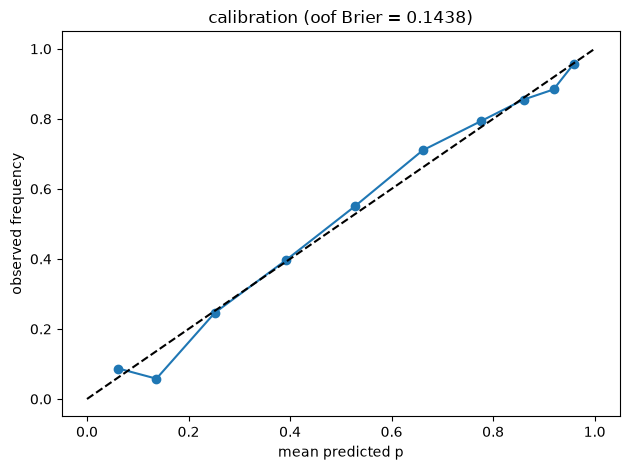

In [34]:
frac_pos, mean_pred=calibration_curve(y_train,p_oof,n_bins=10,strategy='quantile')
plt.plot(mean_pred, frac_pos, 'o-')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('mean predicted p'); plt.ylabel('observed frequency')
plt.title(f'calibration (oof Brier = {brier_score_loss(y_train, p_oof):.4f})')
plt.tight_layout()

In [35]:
p_test=final_model.predict_proba(X_test)[:,1]
rows.append(score(y_test,p_test,thresh=0.5,name='FInal model 0.5 thresh',split='test'))
rows.append(score(y_test,p_test,thresh=THRESHOLD,name=f'final model @ {THRESHOLD:.2f}',split='test'))
rows.append(score(y_train, p_oof, thresh=0.5, name='final model (OOF) 0.5 thresh',split='oof'))
rows.append(score(y_train, p_oof, thresh=THRESHOLD, name=f'final model (OOF) @ {THRESHOLD:.2f}',split='oof'))

pd.DataFrame(rows)

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,avg_precision,brier
0,dummy prior,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.247
1,dummy most_frequent,train,0.5,0.554,0.554,1.000,0.713,0.500,0.554,0.446
2,dummy stratified,train,0.5,0.510,0.558,0.559,0.558,0.504,0.556,0.490
3,base log reg,train,0.5,0.815,0.819,0.856,0.837,0.881,0.888,0.137
4,FInal model 0.5 thresh,test,0.5,0.817,0.820,0.858,0.838,0.891,0.891,0.131
5,final model @ 0.20,test,0.2,0.743,0.687,0.984,0.809,0.891,0.891,0.131
6,final model (OOF) 0.5 thresh,oof,0.5,0.801,0.811,0.835,0.823,0.869,0.873,0.144
7,final model (OOF) @ 0.20,oof,0.2,0.735,0.684,0.971,0.803,0.869,0.873,0.144


In [36]:
pd.concat([g_train.value_counts(normalize=True).rename('train'),
           g_test.value_counts(normalize=True).rename('test')], axis=1)

,train,test
site,,
cleveland,0.331395,0.326087
hungary,0.313953,0.334783
va,0.226744,0.186957
switzerland,0.127907,0.152174


In [37]:
y_pred=(p_test>=THRESHOLD).astype(int)
print((REPORTS_DIR / 'classification_report.txt').read_text(encoding='utf-8'))

              precision    recall  f1-score   support

           0      0.958     0.447     0.609       103
           1      0.687     0.984     0.809       127

    accuracy                          0.743       230
   macro avg      0.823     0.715     0.709       230
weighted avg      0.808     0.743     0.720       230



## Cell 77 -- confusion matrix and test calibration

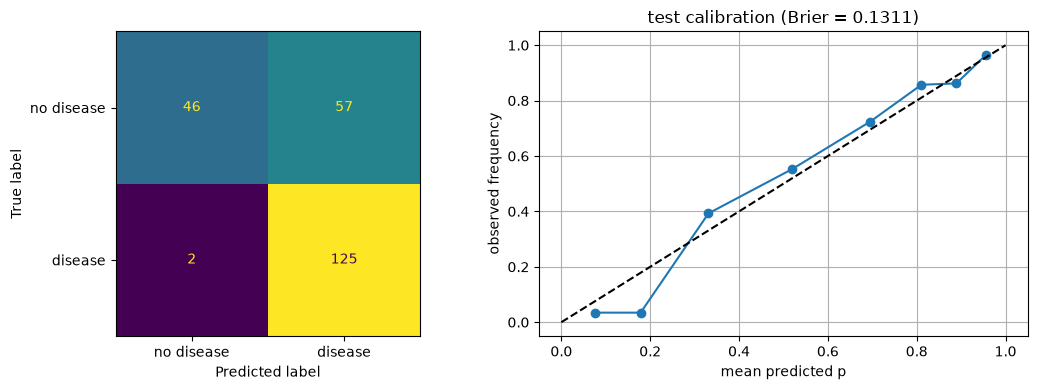

In [38]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred),
                       display_labels=['no disease','disease']).plot(ax=ax[0],colorbar=False)

frac_pos, mean_pred=calibration_curve(y_test,p_test,n_bins=8,strategy='quantile')
ax[1].plot(mean_pred, frac_pos, 'o-')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('mean predicted p'); ax[1].set_ylabel('observed frequency')
plt.title(f'test calibration (Brier = {brier_score_loss(y_test,p_test):.4f})')
plt.tight_layout();ax[1].grid(True)